# Logistic Regression: Binary Classification Analysis

## Overview
Logistic Regression is used to model the probability of a discrete outcome. Unlike Linear Regression, it uses the **Sigmoid Function** to map any real-valued number into a value between 0 and 1.

## Mathematical Formulation
The prediction is made using:
$$\hat{y} = \sigma(w^T X + b)$$
where $\sigma(z) = \frac{1}{1 + e^{-z}}$

We optimize the weights using **Gradient Descent** to minimize the Binary Cross-Entropy loss.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mlpackage import LogisticRegression, StandardScaler, accuracy_score
from sklearn.datasets import make_moons

# 1. Generate 'Moons' dataset (slightly non-linear but separable enough for Logistic)
X, y = make_moons(n_samples=200, noise=0.15, random_state=42)

# 2. Scale features (Important for Gradient Descent convergence!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Train the model
# We'll use a slightly higher iteration count to ensure convergence
model = LogisticRegression(learning_rate=0.1, n_iters=1500)
model.fit(X_scaled, y)

# 4. Evaluation
y_pred = model.predict(X_scaled)
acc = accuracy_score(y, y_pred)
print(f"Training Accuracy: {acc * 100:.2f}%")

Training Accuracy: 84.00%


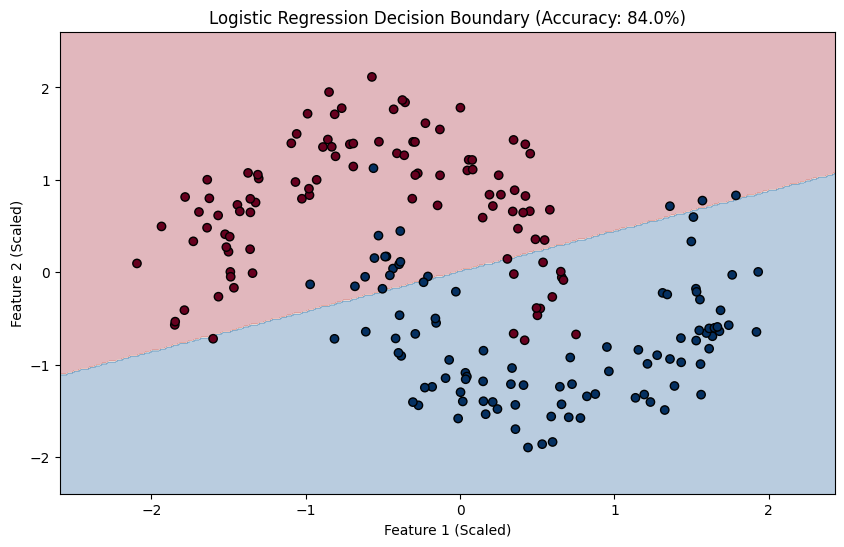

In [2]:
# Create a grid to plot the decision boundary
x_min, x_max = X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5
y_min, y_max = X_scaled[:, 1].min() - 0.5, X_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Predict across the entire grid
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plotting
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, edgecolors='k', cmap='RdBu')
plt.title(f"Logistic Regression Decision Boundary (Accuracy: {acc*100:.1f}%)")
plt.xlabel("Feature 1 (Scaled)")
plt.ylabel("Feature 2 (Scaled)")
plt.show()